Treinaremos com 9418 elementos e testaremos com 3000 elementos
A acurácia foi 65.10%
O F1 Score foi 0.66
Matriz de Confusão:
 [[1324  694]
 [ 353  629]]


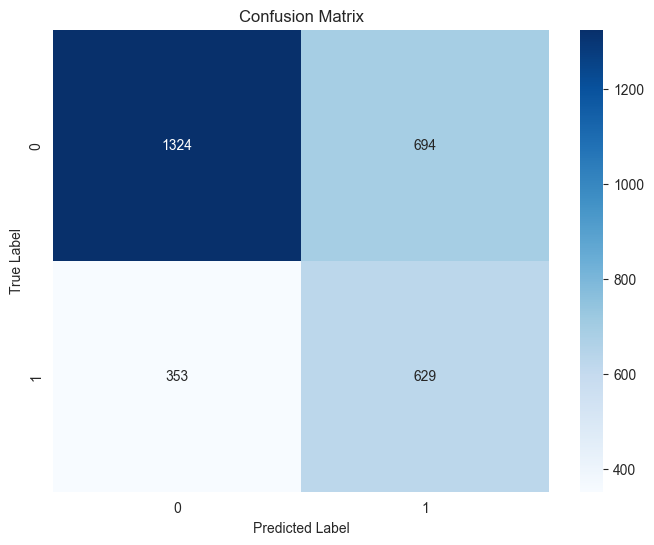

In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from imblearn.over_sampling import SMOTE  # Import SMOTE

# Load the dataset
data = pd.read_csv('data/domestic_violence_fake_data.csv')

# Split the data into features and target label Age
x = data[["Age", "Exchange_Sex", "Children", "Suicide_Attempt", "Jail", "Male", "LGBQ", "White", "Literal_Homeless", "Weapon", "Gang", "PTSD", "Depressed", "Community_Violence", "Sexual_Abuse", "Hard_Drug_Use", "Foster_Care", "Job"]]
y = data["Victim"]

# Split the data (keeping a high test size for demonstration purposes)
raw_train_x, raw_test_x, train_y, test_y = train_test_split(x, y, test_size=0.30, stratify=y)

# Apply SMOTE to the training data only
smote = SMOTE(random_state=42)
train_x_smote, train_y_smote = smote.fit_resample(raw_train_x, train_y)

# Scale the data
scaler = StandardScaler()
scaler.fit(train_x_smote)
train_x = scaler.transform(train_x_smote)
test_x = scaler.transform(raw_test_x)

# Train the model
modelo = SVC()
modelo.fit(train_x, train_y_smote)

# Make predictions
prevision = modelo.predict(test_x)
print("Treinaremos com %d elementos e testaremos com %d elementos" % (len(train_x), len(test_x)))

# Calculate accuracy
accuracy_value = accuracy_score(test_y, prevision) * 100
print("A acurácia foi %.2f%%" % accuracy_value)

# Calculate F1 score
f1_value = f1_score(test_y, prevision, average="weighted")  # Use 'weighted' for imbalanced classes
print("O F1 Score foi %.2f" % f1_value)

# Generate confusion matrix
conf_matrix = confusion_matrix(test_y, prevision)
print("Matriz de Confusão:\n", conf_matrix)

# Plot the confusion matrix
plt.figure(figsize=(8,6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.show()